<a href="https://colab.research.google.com/github/vikranthrach/IIT-Patna--AI-and-ML-Course/blob/main/Zepto_%26_Blinkit_workshop_14th_June_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ How Analysts at Zepto & Blinkit Make Decisions in Minutes
### Hands-on Data Visualization — Matplotlib & Seaborn

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global chart defaults — run this once, applies to everything below (Run Commands Parameters is a dictionary of Matplotlib Configuration settings)
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Shared palette and named colors — we'll use these throughout
PALETTE = sns.color_palette("Set2")
ORANGE  = "#E67E22"
BLUE    = "#2980B9"
RED     = "#E74C3C"
GREEN   = "#27AE60"

print("✅ Libraries loaded and defaults set")

✅ Libraries loaded and defaults set


In [ ]:
# ─── Dataset Generation ───────────────────────────────────────────────────────
# Generates zepto_orders.csv — run once per Colab session.

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

rng = np.random.default_rng(42)
N = 3500

cities = ["Bengaluru","Mumbai","Delhi","Hyderabad","Pune","Chennai"]
city_w = [0.25, 0.20, 0.20, 0.15, 0.10, 0.10]

dark_stores = {
    "Bengaluru": ["Koramangala DS","Indiranagar DS","HSR Layout DS"],
    "Mumbai":    ["Andheri DS","Bandra DS","Powai DS"],
    "Delhi":     ["CP Dark Store","Lajpat Nagar DS","Dwarka DS"],
    "Hyderabad": ["Banjara Hills DS","Gachibowli DS"],
    "Pune":      ["Kothrud DS","Wakad DS"],
    "Chennai":   ["T Nagar DS","Velachery DS"],
}

categories = ["Fruits & Vegetables","Dairy & Breakfast","Snacks & Munchies",
              "Beverages","Personal Care","Household","Staples & Grains","Frozen Veg"]
cat_w = [0.18, 0.22, 0.14, 0.12, 0.10, 0.08, 0.11, 0.05]

products = {
    "Fruits & Vegetables": ["Tomatoes 500g","Onions 1kg","Potatoes 1kg","Spinach Bunch",
                            "Bananas 6pcs","Apples 4pcs","Capsicum 3pcs"],
    "Dairy & Breakfast":   ["Amul Milk 1L","Curd 400g","Paneer 200g","Amul Butter 100g",
                            "Britannia Cheese Slices","Quaker Oats 500g","Bread Loaf"],
    "Snacks & Munchies":   ["Lays Classic 26g","Kurkure Masala","Parle-G 250g",
                            "Haldiram's Namkeen","Popcorn Butter","Digestive Biscuits"],
    "Beverages":           ["Real Mango Juice","Coconut Water","Limca 750ml",
                            "Paper Boat Aam Panna","Horlicks 200g","Minute Maid"],
    "Personal Care":       ["Dove Shampoo 180ml","Himalaya Face Wash","Colgate Toothpaste",
                            "Dettol Soap","Nivea Body Lotion","Sunscreen SPF50"],
    "Household":           ["Vim Dish Wash 500g","Harpic Floor Cleaner","Tissue Paper Pack",
                            "Garbage Bags 30pcs","Lizol Disinfectant 500ml"],
    "Staples & Grains":    ["Basmati Rice 1kg","Aashirvaad Atta 1kg","Toor Dal 500g",
                            "Sugar 1kg","Saffola Gold Oil 1L","Iodized Salt 1kg"],
    "Frozen Veg":          ["Veg Momos 400g","Frozen Peas 500g","Corn Kernels 500g",
                            "Mixed Vegetables 500g","Edamame 200g"],
}

price_range = {
    "Fruits & Vegetables": (25,120), "Dairy & Breakfast":(30,200),
    "Snacks & Munchies":(15,80),     "Beverages":(20,130),
    "Personal Care":(60,380),        "Household":(50,260),
    "Staples & Grains":(40,220),     "Frozen Veg":(80,250),
}

dt_params = {
    "Bengaluru":(22,7), "Mumbai":(20,6), "Delhi":(18,5),
    "Hyderabad":(16,4), "Pune":(14,4),   "Chennai":(17,5),
}

payment_modes = ["UPI","Card","Cash","Wallet"]
pay_w         = [0.60, 0.22, 0.10, 0.08]

hour_probs = np.array([
    0.005,0.003,0.002,0.001,0.002,0.005,
    0.012,0.032,0.055,0.045,0.028,0.022,
    0.038,0.055,0.040,0.030,0.035,0.048,
    0.065,0.080,0.090,0.075,0.055,0.030,
])
hour_probs /= hour_probs.sum()

hour_probs_wknd = hour_probs.copy()
hour_probs_wknd[7:10] *= 1.5
hour_probs_wknd[18:22] *= 1.3
hour_probs_wknd /= hour_probs_wknd.sum()

slot_dt_mult = {
    "Morning (6-11am)":0.90, "Afternoon (11am-4pm)":0.95,
    "Evening (4-9pm)":1.18,  "Night (9pm+)":1.05,
}

def get_slot(h):
    if 6<=h<11:  return "Morning (6-11am)"
    if 11<=h<16: return "Afternoon (11am-4pm)"
    if 16<=h<21: return "Evening (4-9pm)"
    return "Night (9pm+)"

rows = []
base = datetime(2024, 11, 1)
for i in range(N):
    city     = rng.choice(cities, p=city_w)
    store    = rng.choice(dark_stores[city])
    category = rng.choice(categories, p=cat_w)
    product  = rng.choice(products[category])
    lo,hi    = price_range[category]
    mrp      = float(rng.integers(lo, hi+1))
    disc_pct = float(rng.choice([0,5,10,15,20,25],p=[0.35,0.15,0.20,0.15,0.10,0.05]))
    sell_px  = round(mrp*(1-disc_pct/100), 2)
    qty      = int(rng.choice([1,2,3], p=[0.65,0.25,0.10]))

    order_day = int(rng.integers(0, 30))
    tmp_date  = base + timedelta(days=order_day)
    weekday   = tmp_date.strftime('%a')
    probs     = hour_probs_wknd if weekday in ('Sat','Sun') else hour_probs
    hour      = int(rng.choice(24, p=probs))
    slot      = get_slot(hour)
    order_time = tmp_date + timedelta(hours=hour, minutes=int(rng.integers(0,60)))

    status = rng.choice(["Delivered","Cancelled"], p=[0.95, 0.05])
    mu,sd  = dt_params[city]
    dt     = int(np.clip(rng.normal(mu*slot_dt_mult[slot], sd), 7, 50)) if status=="Delivered" else np.nan
    rating = float(np.round(np.clip(rng.normal(4.0,0.7),1.0,5.0),1))
    if status=="Cancelled" or rng.random()<0.12:
        rating = np.nan

    rows.append({
        "order_id":f"ZBL{200000+i}", "order_time":order_time,
        "hour":hour, "day_of_week":weekday, "slot":slot,
        "city":city, "dark_store":store, "category":category, "product":product,
        "mrp":mrp, "selling_price":sell_px, "discount_pct":disc_pct,
        "quantity":qty, "order_total":round(sell_px*qty,2),
        "delivery_time_min":dt, "promised_min":10,
        "payment_mode":rng.choice(payment_modes, p=pay_w),
        "rating":rating, "status":status,
    })

df = pd.DataFrame(rows)
df.to_csv("zepto_orders.csv", index=False)
print(f"✅ zepto_orders.csv — {len(df):,} rows, {df.shape[1]} columns")
print(f"   Delivered: {(df.status=='Delivered').sum():,}  |  Cancelled: {(df.status=='Cancelled').sum():,}")
print(f"   Missing delivery_time: {df.delivery_time_min.isna().sum()}  |  Missing rating: {df.rating.isna().sum()}")


✅ zepto_orders.csv — 3,500 rows, 19 columns
   Delivered: 3,301  |  Cancelled: 199
   Missing delivery_time: 199  |  Missing rating: 577


**Key columns:**
- `hour`, `day_of_week`, `slot` — *when* things happen
- `city`, `dark_store` — *where*
- `category`, `product`, `order_total` — *what* and *how much*
- `delivery_time_min`, `promised_min` — *performance* (our main story)
- `rating` — *customer feedback*

**Our premise:** Zepto/Blinkit promise **10-minute delivery**. All the charts today either prove or disprove that — and explain why.


In [ ]:
# Load and get a quick look
df = pd.read_csv("zepto_orders.csv", parse_dates=["order_time"])

# We'll use 'delivered' for most charts — cancelled orders have no delivery time
delivered = df[df["status"] == "Delivered"].copy()

print("Shape:", df.shape)
df.head()

Shape: (3500, 19)


,order_id,order_time,hour,day_of_week,slot,city,dark_store,category,product,mrp,selling_price,discount_pct,quantity,order_total,delivery_time_min,promised_min,payment_mode,rating,status
0,ZBL200000,2024-11-21 20:43:00,20,Thu,Evening (4-9pm),Hyderabad,Gachibowli DS,Staples & Grains,Toor Dal 500g,55.0,55.0,0.0,3,165.0,15.0,10,Card,4.6,Delivered
1,ZBL200001,2024-11-26 19:49:00,19,Tue,Evening (4-9pm),Pune,Wakad DS,Snacks & Munchies,Parle-G 250g,29.0,26.1,10.0,1,26.1,13.0,10,Card,4.9,Delivered
2,ZBL200002,2024-11-05 23:24:00,23,Tue,Night (9pm+),Bengaluru,Indiranagar DS,Fruits & Vegetables,Spinach Bunch,77.0,69.3,10.0,2,138.6,27.0,10,UPI,4.8,Delivered
3,ZBL200003,2024-11-03 21:18:00,21,Sun,Night (9pm+),Bengaluru,Koramangala DS,Personal Care,Sunscreen SPF50,200.0,170.0,15.0,2,340.0,23.0,10,UPI,4.2,Delivered
4,ZBL200004,2024-11-20 16:30:00,16,Wed,Evening (4-9pm),Bengaluru,HSR Layout DS,Household,Vim Dish Wash 500g,214.0,181.9,15.0,2,363.8,36.0,10,UPI,3.4,Delivered


In [ ]:
df.describe().round(2)

,order_time,hour,mrp,selling_price,discount_pct,quantity,order_total,delivery_time_min,promised_min,rating
count,3500,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3301.00,3500.0,2923.00
mean,2024-11-16 05:12:34.782857216,15.49,109.94,100.86,8.22,1.45,145.67,18.96,10.0,3.99
min,2024-11-01 00:43:00,0.00,15.00,11.25,0.00,1.00,12.75,7.00,10.0,1.60
25%,2024-11-08 17:49:00,11.00,58.00,53.00,0.00,1.00,64.60,14.00,10.0,3.50
50%,2024-11-16 07:18:00,17.00,93.00,85.00,10.00,1.00,111.00,18.00,10.0,4.00
75%,2024-11-23 16:37:15,20.00,148.00,135.00,15.00,2.00,186.15,23.00,10.0,4.50
max,2024-11-30 23:52:00,23.00,379.00,379.00,25.00,3.00,934.80,41.00,10.0,5.00
std,NaN,5.27,69.87,64.75,7.66,0.66,118.33,6.36,0.0,0.66


# Question: at which hour do the most orders come in?

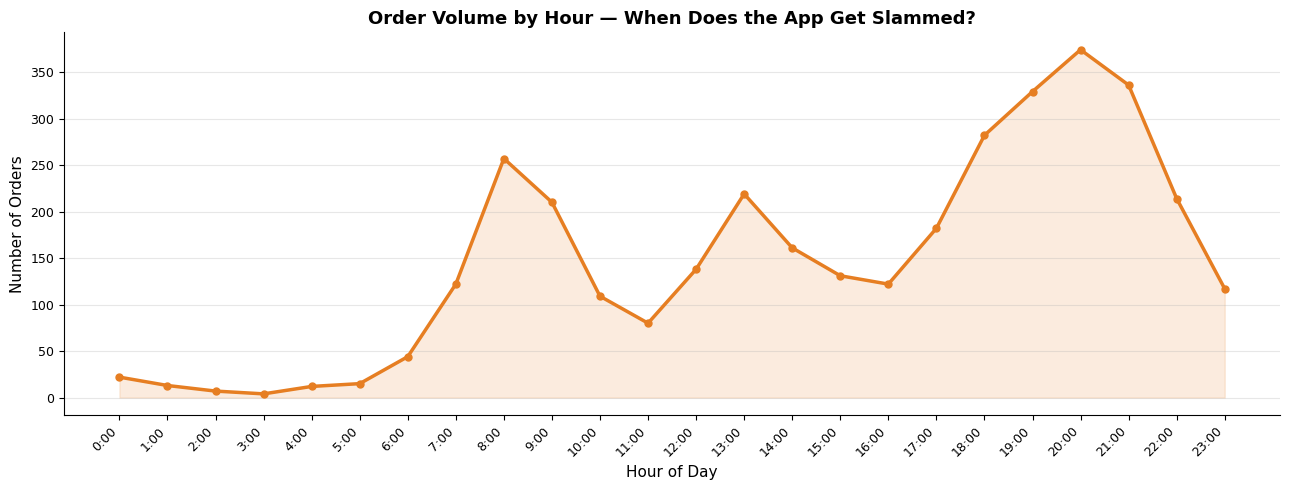

In [ ]:
hourly=df.groupby("hour")["order_id"].count().reset_index()
hourly.columns=["Hour", "Orders"]
fig, ax = plt.subplots(figsize=(13,5))

ax.plot(hourly["Hour"], hourly["Orders"],
        color=ORANGE, linewidth=2.5, marker="o", markersize=5, zorder=3)
ax.fill_between(hourly["Hour"], hourly["Orders"], alpha=0.15, color=ORANGE)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Orders")
ax.set_title("Order Volume by Hour — When Does the App Get Slammed?", fontweight="bold")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# Question: which city drives the most orders?

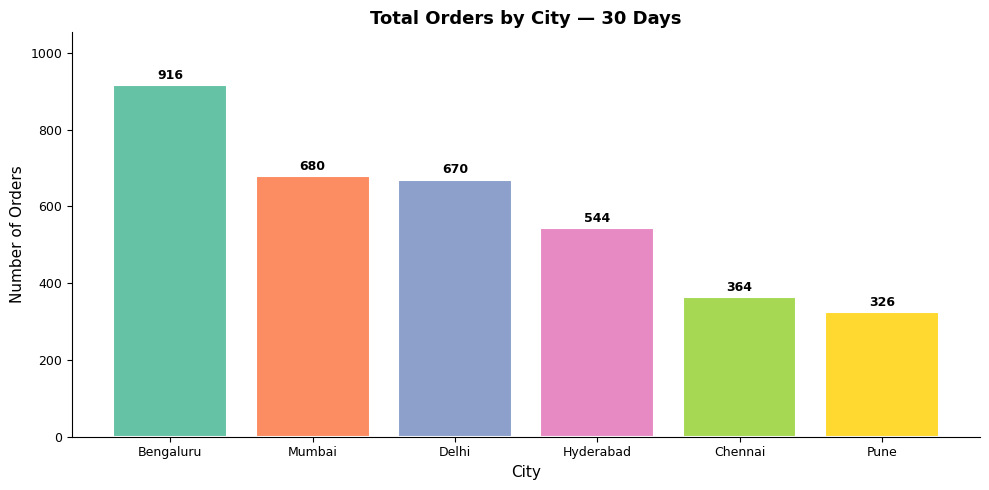

In [ ]:
city_counts=df["city"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(city_counts.index, city_counts.values,
              color=PALETTE[:len(city_counts)], edgecolor="white", linewidth=1.5)

# Add value labels ON TOP of each bar — always do this
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f'{int(bar.get_height()):,}',
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("City")
ax.set_ylabel("Number of Orders")
ax.set_title("Total Orders by City — 30 Days", fontweight="bold")
ax.set_ylim(0, city_counts.max() * 1.15)
plt.tight_layout()
plt.show()


**"Which category is making us the most total revenue?"**

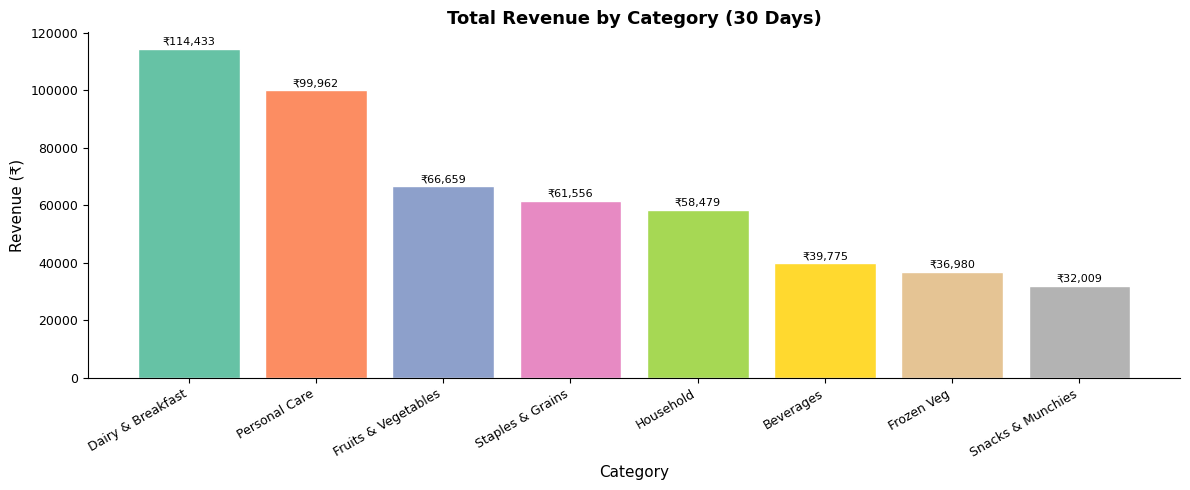

In [ ]:
cat_revenue=df.groupby("category")["order_total"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cat_revenue.index, cat_revenue.values,
              color=PALETTE[:len(cat_revenue)], edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'₹{int(bar.get_height()):,}', ha="center", va="bottom", fontsize=8)
ax.set_title("Total Revenue by Category (30 Days)", fontweight="bold")
ax.set_ylabel("Revenue (₹)")
ax.set_xlabel("Category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Question: do bigger orders get delivered faster?
# Maybe Zepto prioritises premium orders? Let's find out.

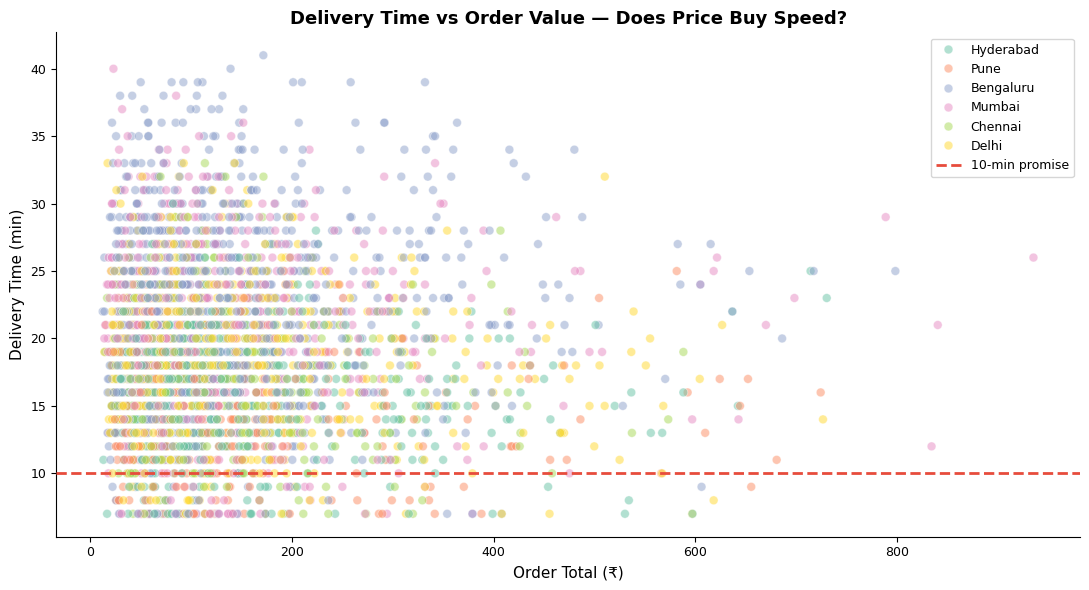

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(data=delivered, x="order_total", y="delivery_time_min",
                hue="city", palette="Set2", alpha=0.5, s=40, ax=ax)

# The promise line — everything below this is a win
ax.axhline(10, color=RED, linestyle="--", linewidth=2,
           label="10-min promise", zorder=5)

ax.set_xlabel("Order Total (₹)")
ax.set_ylabel("Delivery Time (min)")
ax.set_title("Delivery Time vs Order Value — Does Price Buy Speed?", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

**Follow-up question:** *"Do slow deliveries lead to lower ratings?"*

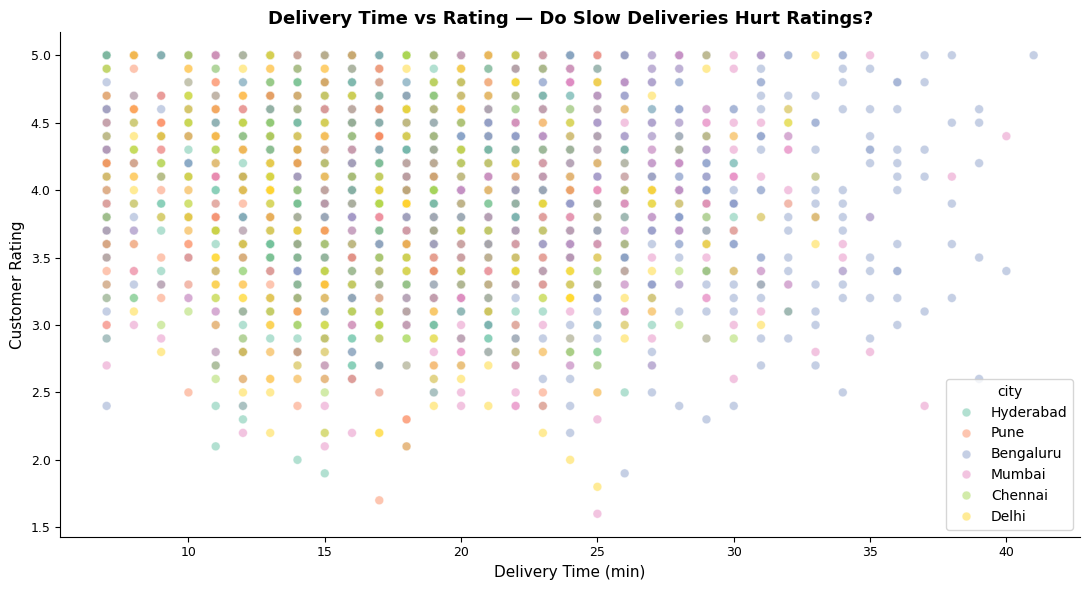

In [ ]:
df_rated=delivered.dropna(subset=["rating"])
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=df_rated, x="delivery_time_min", y="rating",
                hue="city", palette="Set2", alpha=0.5, s=40, ax=ax)
ax.set_xlabel("Delivery Time (min)")
ax.set_ylabel("Customer Rating")
ax.set_title("Delivery Time vs Rating — Do Slow Deliveries Hurt Ratings?", fontweight="bold")
plt.tight_layout()
plt.show()

**Business question:** *"We promise 10-minute delivery. What does the actual distribution look like — are we even close?"*

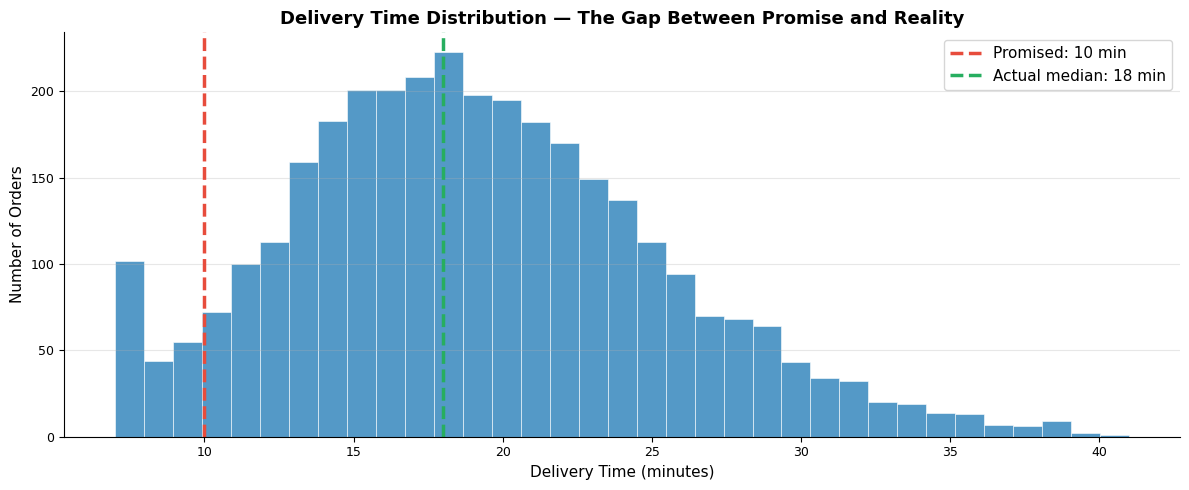

10th percentile : 11.0 min  (fastest 10% of orders)
Median          : 18.0 min
90th percentile : 28.0 min  (slowest 10%)
Within 10 min   : 8.3% of orders


In [ ]:
dt_data = delivered["delivery_time_min"].dropna()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(dt_data, bins=35, color=BLUE, alpha=0.8, edgecolor="white", linewidth=0.5)

# The 10-min promise — where EVERYTHING should be
ax.axvline(10, color=RED, linestyle="--", linewidth=2.5,
           label="Promised: 10 min")

# The actual median — where orders actually land
ax.axvline(dt_data.median(), color=GREEN, linestyle="--", linewidth=2.5,
           label=f"Actual median: {dt_data.median():.0f} min")

ax.set_xlabel("Delivery Time (minutes)")
ax.set_ylabel("Number of Orders")
ax.set_title("Delivery Time Distribution — The Gap Between Promise and Reality",
             fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"10th percentile : {dt_data.quantile(0.10):.1f} min  (fastest 10% of orders)")
print(f"Median          : {dt_data.median():.1f} min")
print(f"90th percentile : {dt_data.quantile(0.90):.1f} min  (slowest 10%)")
print(f"Within 10 min   : {(dt_data <= 10).mean()*100:.1f}% of orders")

#Boxplot - Delivery Time by City

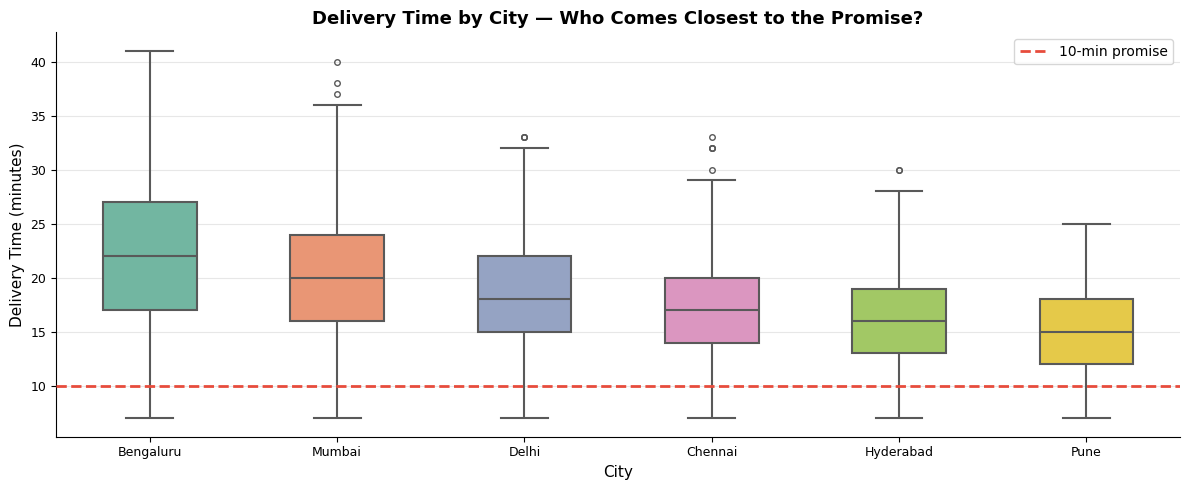

In [ ]:
city_med_order = (delivered.groupby("city")["delivery_time_min"]
                                          .median()
                                          .sort_values(ascending=False)).index
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=delivered, x="city", y="delivery_time_min",
            order=city_med_order,  palette="Set2",
            width=0.5, linewidth=1.5, fliersize=4, ax=ax)
ax.axhline(10, color=RED, linestyle="--", linewidth=2,
           label="10-min promise", zorder=5)

ax.set_xlabel("City")
ax.set_ylabel("Delivery Time (minutes)")
ax.set_title("Delivery Time by City — Who Comes Closest to the Promise?",
             fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Follow-up:** *"Does the time slot affect delivery speed? Is Evening really slower?"*

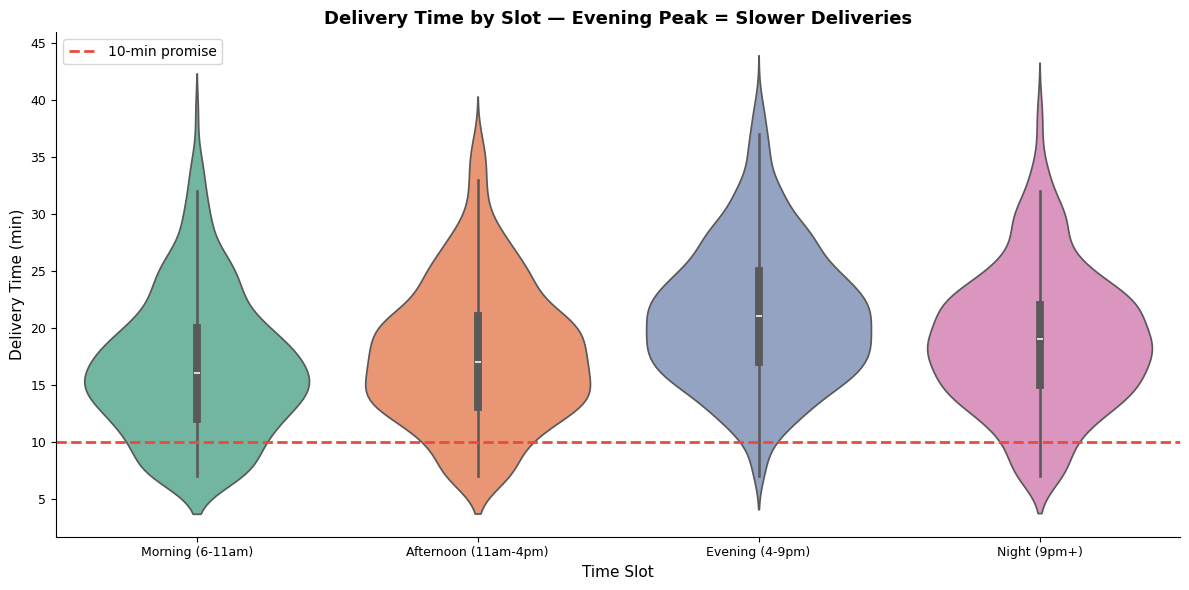

In [ ]:
slot_order = ["Morning (6-11am)", "Afternoon (11am-4pm)", "Evening (4-9pm)", "Night (9pm+)"]
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=delivered, x="slot", y="delivery_time_min",
               order=slot_order, palette="Set2", inner="box", ax=ax)
ax.axhline(10, color=RED, linestyle="--", linewidth=2, label="10-min promise")
ax.set_title("Delivery Time by Slot — Evening Peak = Slower Deliveries", fontweight="bold")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Delivery Time (min)")
ax.legend()
plt.tight_layout()
plt.show()

**Business question:** *"When are we getting the most orders? When are we slowest? I want to see it by day AND by time."*

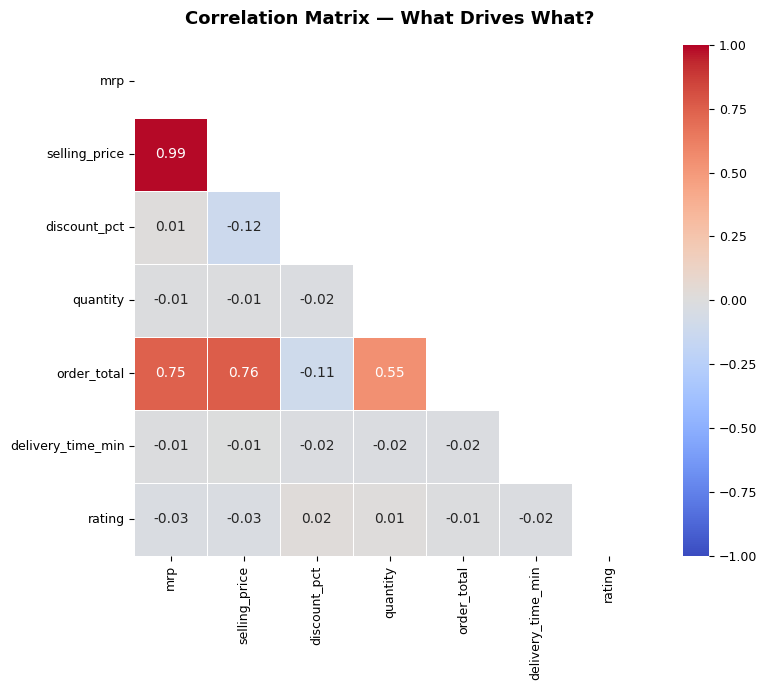

In [ ]:
numeric_cols = ["mrp","selling_price","discount_pct","quantity",
                "order_total","delivery_time_min","rating"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, linewidths=0.5, linecolor="white",
            square=True, vmin=-1, vmax=1,
            annot_kws={"size": 10}, ax=ax)

ax.set_title("Correlation Matrix — What Drives What?", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

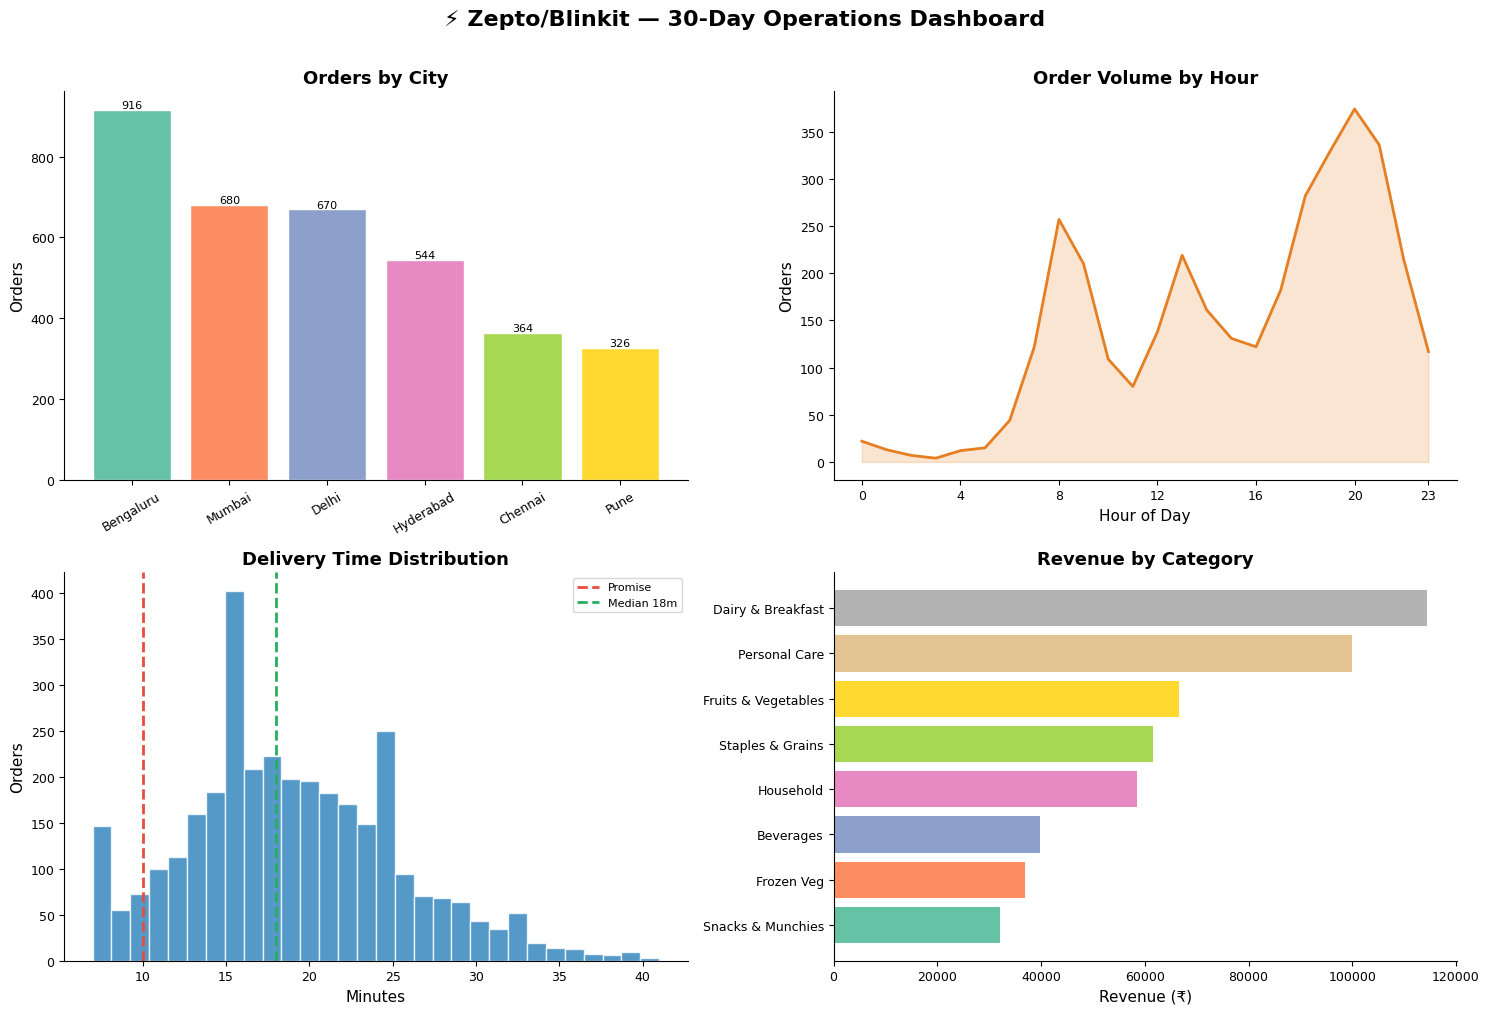

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── [0,0] Orders by City (Bar) ───────────────────────────────────────
city_counts = df["city"].value_counts()
bars = axes[0,0].bar(city_counts.index, city_counts.values,
                     color=PALETTE[:len(city_counts)], edgecolor="white")
axes[0,0].set_title("Orders by City", fontweight="bold")
axes[0,0].set_ylabel("Orders")
axes[0,0].tick_params(axis="x", rotation=30)
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 4, str(int(bar.get_height())),
                   ha="center", fontsize=8)

# ── [0,1] Hourly Trend (Line) ────────────────────────────────────────
hourly = df.groupby("hour")["order_id"].count()
axes[0,1].plot(hourly.index, hourly.values, color=ORANGE, linewidth=2)
axes[0,1].fill_between(hourly.index, hourly.values, alpha=0.2, color=ORANGE)
axes[0,1].set_title("Order Volume by Hour", fontweight="bold")
axes[0,1].set_xlabel("Hour of Day")
axes[0,1].set_ylabel("Orders")
axes[0,1].set_xticks([0, 4, 8, 12, 16, 20, 23])

# ── [1,0] Delivery Time Histogram ────────────────────────────────────
dt_vals = delivered["delivery_time_min"].dropna()
axes[1,0].hist(dt_vals, bins=30, color=BLUE, alpha=0.8, edgecolor="white")
axes[1,0].axvline(10,              color=RED,   linestyle="--", lw=2, label="Promise")
axes[1,0].axvline(dt_vals.median(), color=GREEN, linestyle="--", lw=2,
                  label=f"Median {dt_vals.median():.0f}m")
axes[1,0].set_title("Delivery Time Distribution", fontweight="bold")
axes[1,0].set_xlabel("Minutes")
axes[1,0].set_ylabel("Orders")
axes[1,0].legend(fontsize=8)

# ── [1,1] Revenue by Category (Horizontal Bar) ───────────────────────
# Horizontal because category names are long — they don't fit vertical
cat_rev = df.groupby("category")["order_total"].sum().sort_values()
axes[1,1].barh(cat_rev.index, cat_rev.values, color=PALETTE[:len(cat_rev)])
axes[1,1].set_title("Revenue by Category", fontweight="bold")
axes[1,1].set_xlabel("Revenue (₹)")

# ── Global title ──────────────────────────────────────────────────────
fig.suptitle("⚡ Zepto/Blinkit — 30-Day Operations Dashboard",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()
